<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Stroke-prediction-ANN-Projects/blob/main/Strokes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction System

## 🧠 Stroke — Short Description

**Stroke is a medical emergency that occurs when blood flow to part of the brain is blocked or when a blood vessel in the brain bursts, causing brain cells to die due to lack of oxygen.** It can lead to weakness, speech problems, paralysis, memory loss, or even death if not treated quickly.

---

## ✅ Types of Stroke

* **Ischemic Stroke** → caused by blood clot blockage
* **Hemorrhagic Stroke** → caused by bleeding in the brain
* **TIA (Mini Stroke)** → temporary blockage warning sign.

---

## ⚠️ Common Symptoms

Use **FAST**:

* **F** → Face drooping
* **A** → Arm weakness
* **S** → Speech difficulty
* **T** → Time to call emergency help  ([Mayo Clinic][2])

---

## 📌 project definition

**Stroke is a sudden interruption of blood supply to the brain that damages brain cells and can cause disability or death.**



# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download Dataset From KaggleHub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 67.4k/67.4k [00:00<00:00, 15.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1


In [3]:
os.listdir(path)

['healthcare-dataset-stroke-data.csv']

# Read the Dataset

In [4]:
df=pd.read_csv(path+'/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Data Preprocessing & EDA**

In [5]:
df.rename(columns={'heart_disease':"heart disease","ever_married":"Married","avg_glucose_level":"Avg_Glucose_Level","smoking_status":"Smoking Status","work_type":"Work Type"},inplace=True)

In [6]:
df.head()

,id,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.drop('id',axis=1,inplace=True)

In [8]:
df.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [9]:
df.shape

(5110, 11)

In [10]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart disease,0
Married,0
Work Type,0
Residence_type,0
Avg_Glucose_Level,0
bmi,201
Smoking Status,0


In [11]:
df = df[df['gender'] != 'Other']
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115


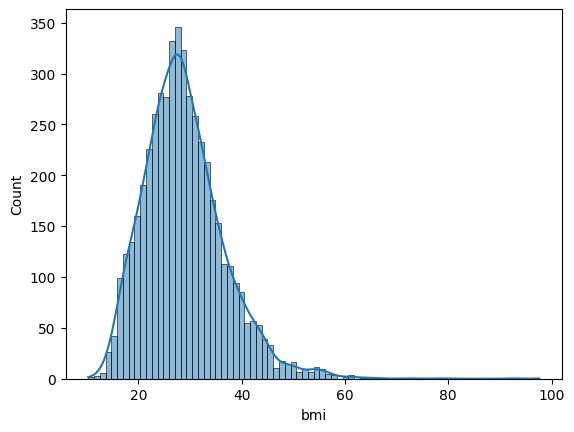

In [12]:
sns.histplot(df['bmi'],kde=True)
plt.show()

In [13]:
df['bmi'].skew()

np.float64(1.0550629490426457)

In [14]:
df['bmi'].mean()

np.float64(28.894559902200488)

In [15]:
df['bmi'].median()

28.1

In [16]:
#df.fillna(df['bmi'].median(),inplace=True)

In [17]:
df['bmi'].isnull().sum()

np.int64(201)

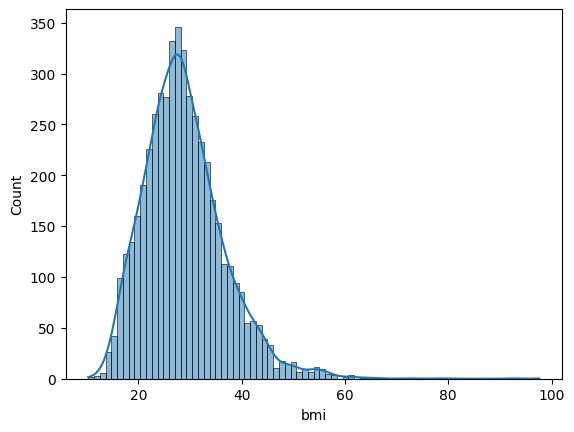

In [18]:
sns.histplot(df['bmi'],kde=True)
plt.show()

In [19]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart disease,0
Married,0
Work Type,0
Residence_type,0
Avg_Glucose_Level,0
bmi,201
Smoking Status,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.sample(5)

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
1875,Male,80.0,1,1,Yes,Private,Urban,86.68,27.7,formerly smoked,0
4808,Male,34.0,0,0,Yes,Private,Rural,84.08,32.9,never smoked,0
1973,Female,17.0,0,0,No,Private,Rural,55.41,25.4,Unknown,0
4793,Male,17.0,0,0,No,Private,Rural,63.82,19.4,smokes,0
4840,Female,31.0,0,0,No,Private,Rural,90.29,38.7,Unknown,0


In [22]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart disease,int64
Married,object
Work Type,object
Residence_type,object
Avg_Glucose_Level,float64
bmi,float64
Smoking Status,object


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart disease      5109 non-null   int64  
 4   Married            5109 non-null   object 
 5   Work Type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   Avg_Glucose_Level  5109 non-null   float64
 8   bmi                4908 non-null   float64
 9   Smoking Status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


In [24]:
df.describe()

,age,hypertension,heart disease,Avg_Glucose_Level,bmi,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,4908.00000,5109.000000
mean,43.229986,0.097475,0.054022,106.140399,28.89456,0.048738
std,22.613575,0.296633,0.226084,45.285004,7.85432,0.215340
min,0.080000,0.000000,0.000000,55.120000,10.30000,0.000000
25%,25.000000,0.000000,0.000000,77.240000,23.50000,0.000000
50%,45.000000,0.000000,0.000000,91.880000,28.10000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.10000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.60000,1.000000


In [25]:
df['age']=df['age'].astype("int64")

In [26]:
df["age"].head()

,age
0,67
1,61
2,80
3,49
4,79


# Check All Unique Values

In [27]:
df['stroke'].value_counts()

,count
stroke,
0,4860
1,249


In [28]:
df['Married'].value_counts()

,count
Married,
Yes,3353
No,1756


In [29]:
df['Smoking Status'].value_counts()

,count
Smoking Status,
never smoked,1892
Unknown,1544
formerly smoked,884
smokes,789


In [30]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115


In [31]:
df['heart disease'].value_counts()

,count
heart disease,
0,4833
1,276


In [32]:
df['hypertension'].value_counts()

,count
hypertension,
0,4611
1,498


In [33]:
df['Work Type'].value_counts()

,count
Work Type,
Private,2924
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [34]:
df['Residence_type'].value_counts()

,count
Residence_type,
Urban,2596
Rural,2513


In [35]:
df['Avg_Glucose_Level'].unique()

array([228.69, 202.21, 105.92, ...,  82.99, 166.29,  85.28])

In [36]:
df['age'].unique()

array([67, 61, 80, 49, 79, 81, 74, 69, 59, 78, 54, 50, 64, 75, 60, 57, 71,
       52, 82, 65, 58, 42, 48, 72, 63, 76, 39, 77, 73, 56, 45, 70, 66, 51,
       43, 68, 47, 53, 38, 55,  1, 46, 32, 14,  3,  8, 37, 40, 35, 20, 44,
       25, 27, 23, 17, 13,  4, 16, 22, 30, 29, 11, 21, 18, 33, 24, 34, 36,
        0, 41,  5, 26, 31,  7, 12, 62,  2,  9, 15, 28, 10, 19,  6])

# Data Visualization

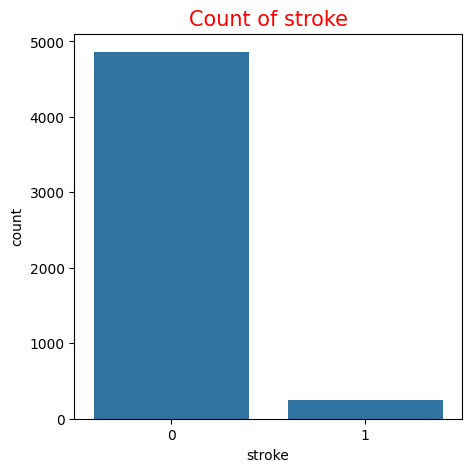

In [37]:
plt.figure(figsize=(5,5))
sns.countplot(x='stroke',data=df)
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

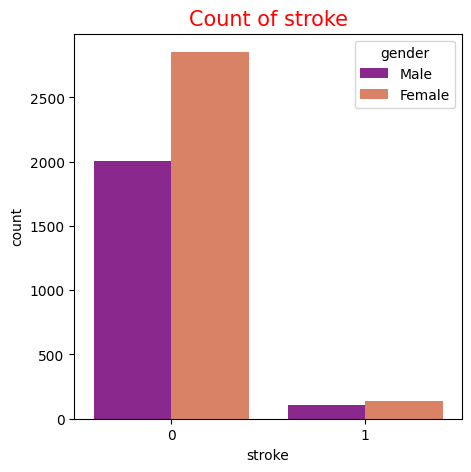

In [38]:
plt.figure(figsize=(5,5))
sns.countplot(x='stroke',data=df,hue='gender',palette='plasma')
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

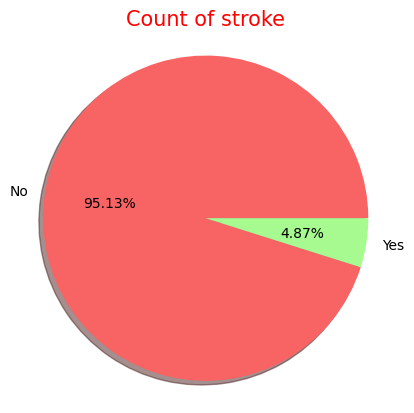

In [39]:
plt.pie(df['stroke'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#F86363","#A6FA8F"],radius=1.1,shadow=True)
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

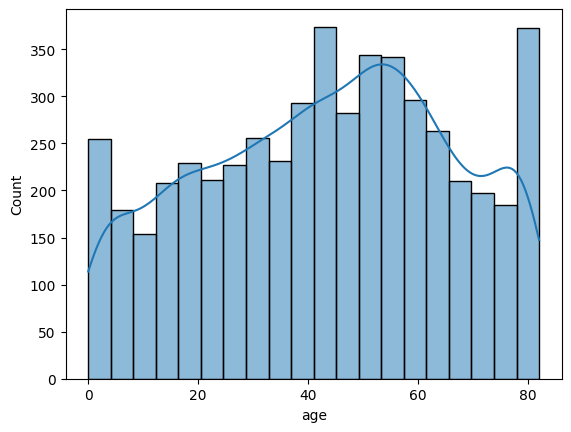

In [40]:
sns.histplot(df['age'],kde=True)
plt.show()

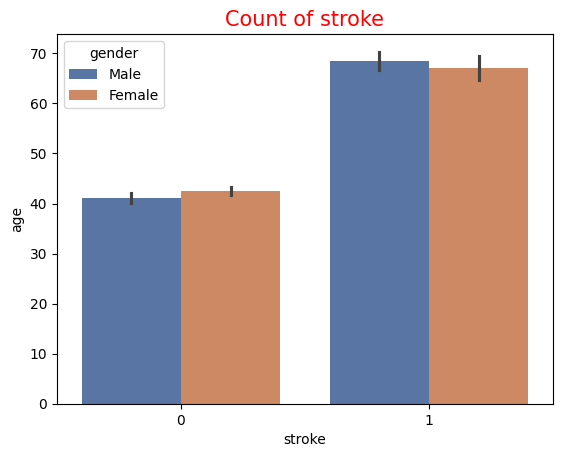

In [41]:
sns.barplot(y='age',x='stroke',data=df,hue="gender",palette='deep')
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

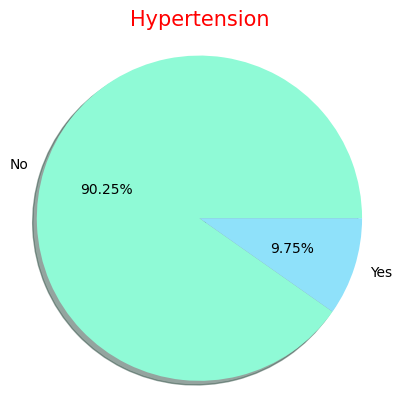

In [42]:
plt.pie(df['hypertension'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#8FFAD6","#8FE1FA"],radius=1.1,shadow=True)
plt.title('Hypertension',color='red',fontsize=15)
plt.show()

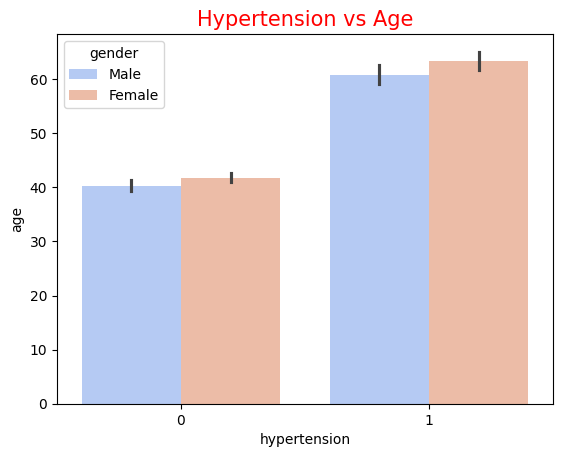

In [43]:
sns.barplot(y='age',x='hypertension',data=df,hue="gender",palette='coolwarm')
plt.title('Hypertension vs Age',color='red',fontsize=15)
plt.show()

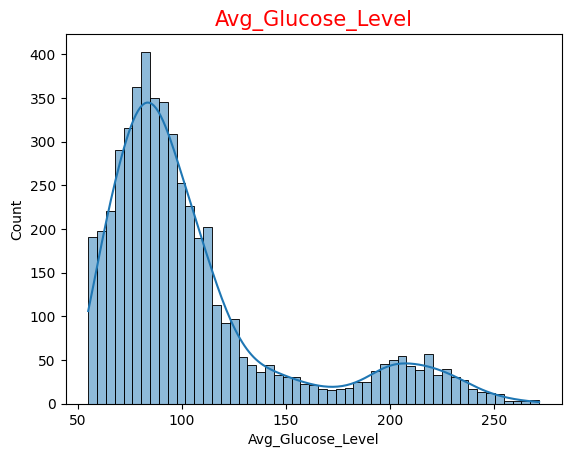

In [44]:
sns.histplot(df['Avg_Glucose_Level'],kde=True)
plt.title('Avg_Glucose_Level',color='red',fontsize=15)
plt.show()

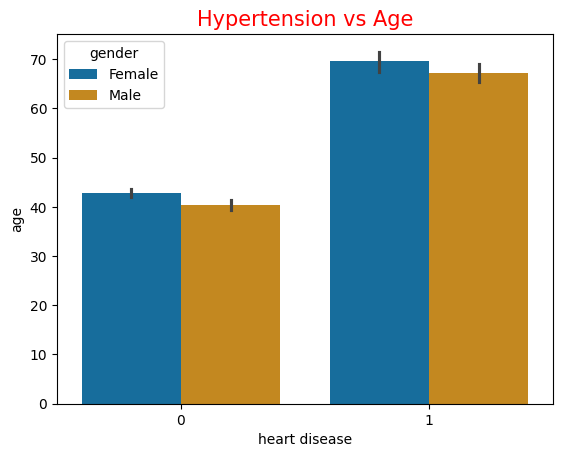

In [45]:
sns.barplot(y='age',x='heart disease',data=df,hue="gender",palette='colorblind')
plt.title('Hypertension vs Age',color='red',fontsize=15)
plt.show()

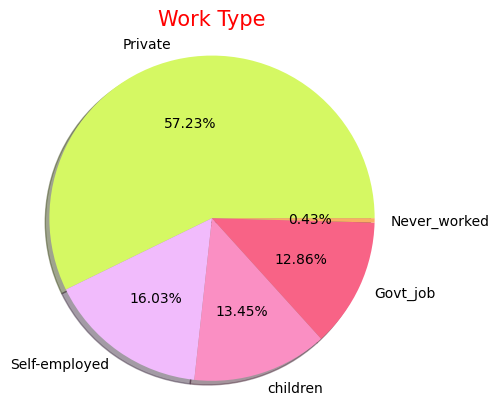

In [46]:
plt.pie(df['Work Type'].value_counts(),labels=df["Work Type"].value_counts().index,autopct='%.2f%%',colors=["#D5F863","#F1BBFC","#FA8FC3","#F86386","#F8B063"],radius=1.1,shadow=True)
plt.title('Work Type',color='red',fontsize=15)
plt.show()

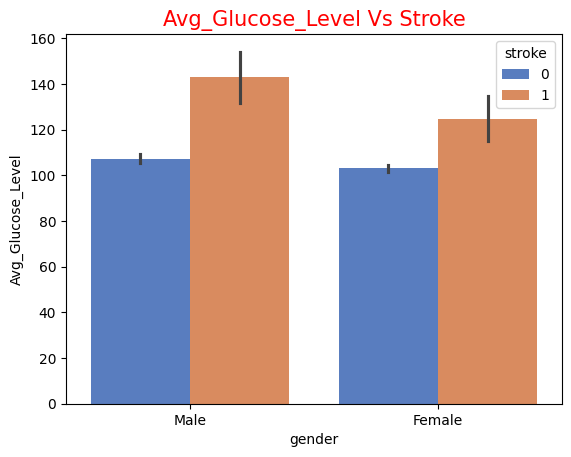

In [47]:
sns.barplot(y='Avg_Glucose_Level',x='gender',data=df,hue="stroke",palette='muted')
plt.title('Avg_Glucose_Level Vs Stroke',color='red',fontsize=15)
plt.show()

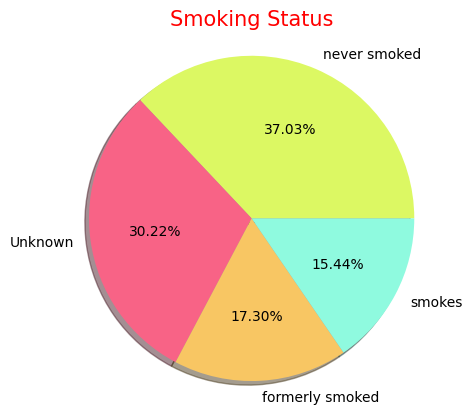

In [48]:
plt.pie(df['Smoking Status'].value_counts(),labels=df["Smoking Status"].value_counts().index,autopct='%.2f%%',colors=["#DCF863","#F86386","#F8C663","#8FFADF"],radius=1.1,shadow=True)
plt.title('Smoking Status',color='red',fontsize=15)
plt.show()

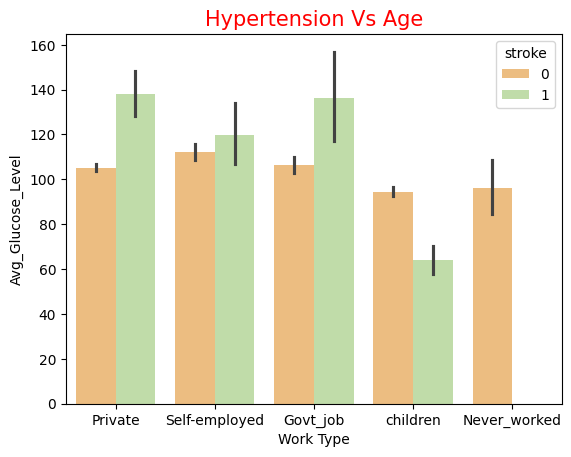

In [49]:
sns.barplot(x='Work Type',y='Avg_Glucose_Level',data=df,hue="stroke",palette='Spectral')
plt.title('Hypertension Vs Age',color='red',fontsize=15)
plt.show()

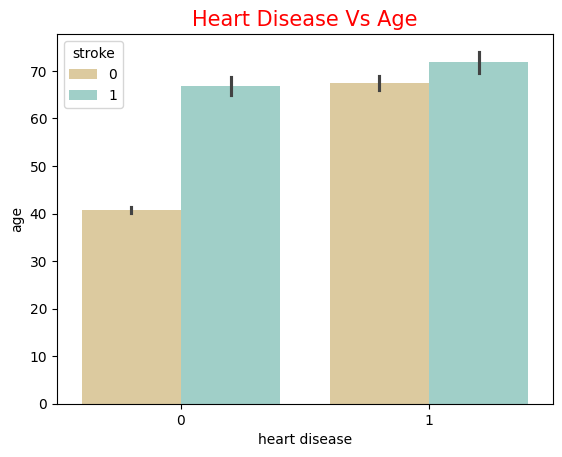

In [50]:
sns.barplot(y='age',x='heart disease',data=df,hue="stroke",palette='BrBG')
plt.title('Heart Disease Vs Age',color='red',fontsize=15)
plt.show()

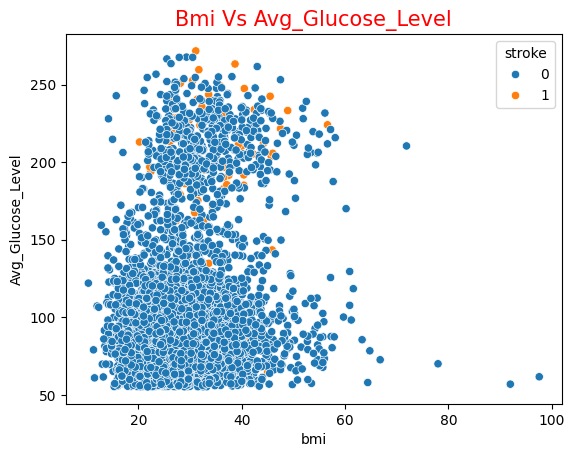

In [51]:
sns.scatterplot(data=df,x="bmi",y="Avg_Glucose_Level",color='blue',marker="o",hue="stroke")
plt.title('Bmi Vs Avg_Glucose_Level',color='red',fontsize=15)
plt.show()

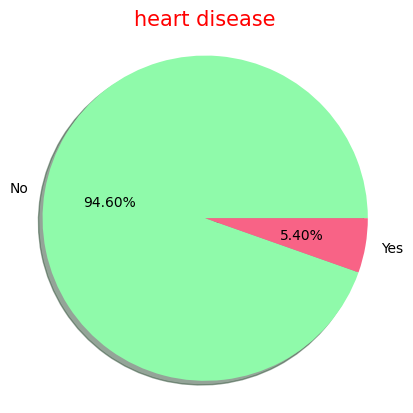

In [52]:
plt.pie(df['heart disease'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#8FFAAA","#F86386"],radius=1.1,shadow=True)
plt.title('heart disease',color='red',fontsize=15)
plt.show()

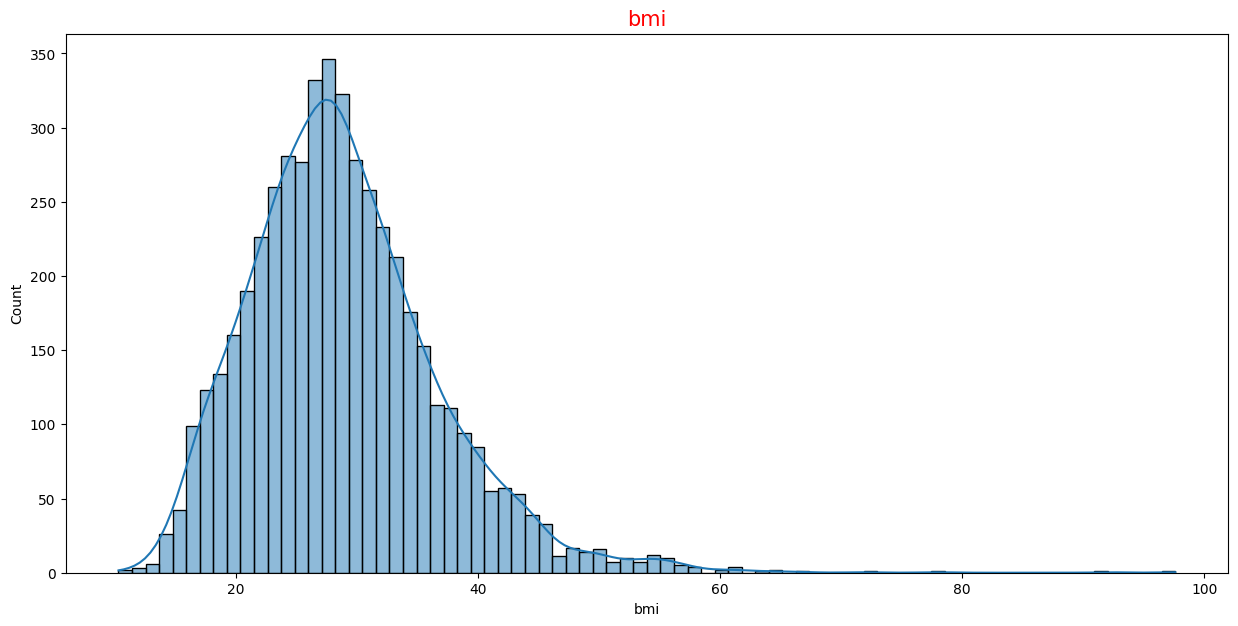

In [53]:
plt.figure(figsize=(15,7))
sns.histplot(df['bmi'],kde=True)
plt.title('bmi',color='red',fontsize=15)
plt.show()

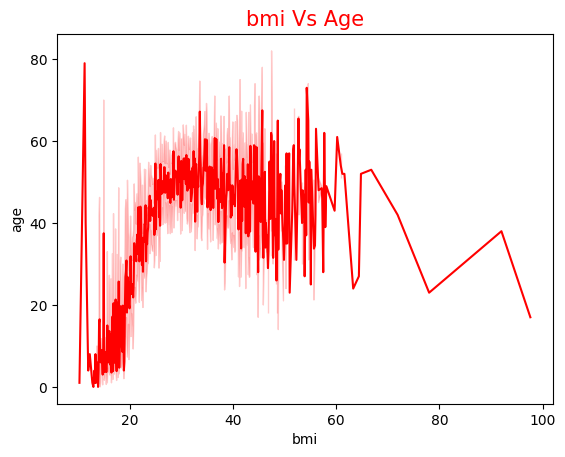

In [54]:
sns.lineplot(data=df,x="bmi",y="age",color='red')
plt.title('bmi Vs Age',color='red',fontsize=15)
plt.show()

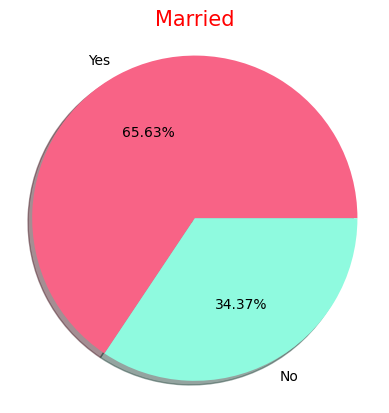

In [55]:
plt.pie(df['Married'].value_counts(),labels=df["Married"].value_counts().index,autopct='%.2f%%',colors=["#F86386","#8FFADF"],radius=1.1,shadow=True)
plt.title('Married',color='red',fontsize=15)
plt.show()

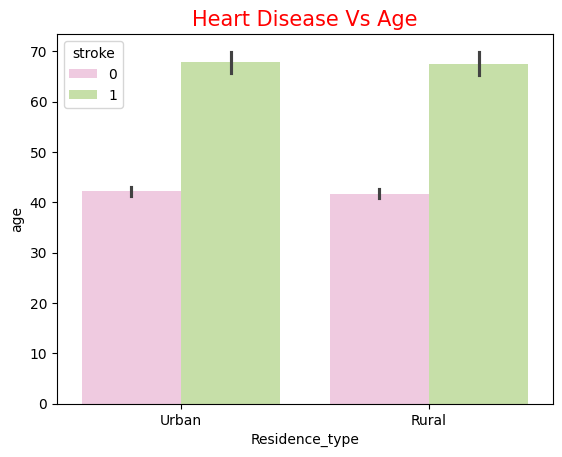

In [56]:
sns.barplot(y='age',x='Residence_type',data=df,hue="stroke",palette='PiYG')
plt.title('Heart Disease Vs Age',color='red',fontsize=15)
plt.show()

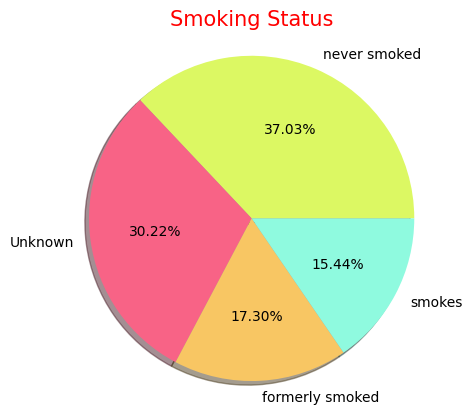

In [57]:
plt.pie(df['Smoking Status'].value_counts(),labels=df["Smoking Status"].value_counts().index,autopct='%.2f%%',colors=["#DCF863","#F86386","#F8C663","#8FFADF"],radius=1.1,shadow=True)
plt.title('Smoking Status',color='red',fontsize=15)
plt.show()

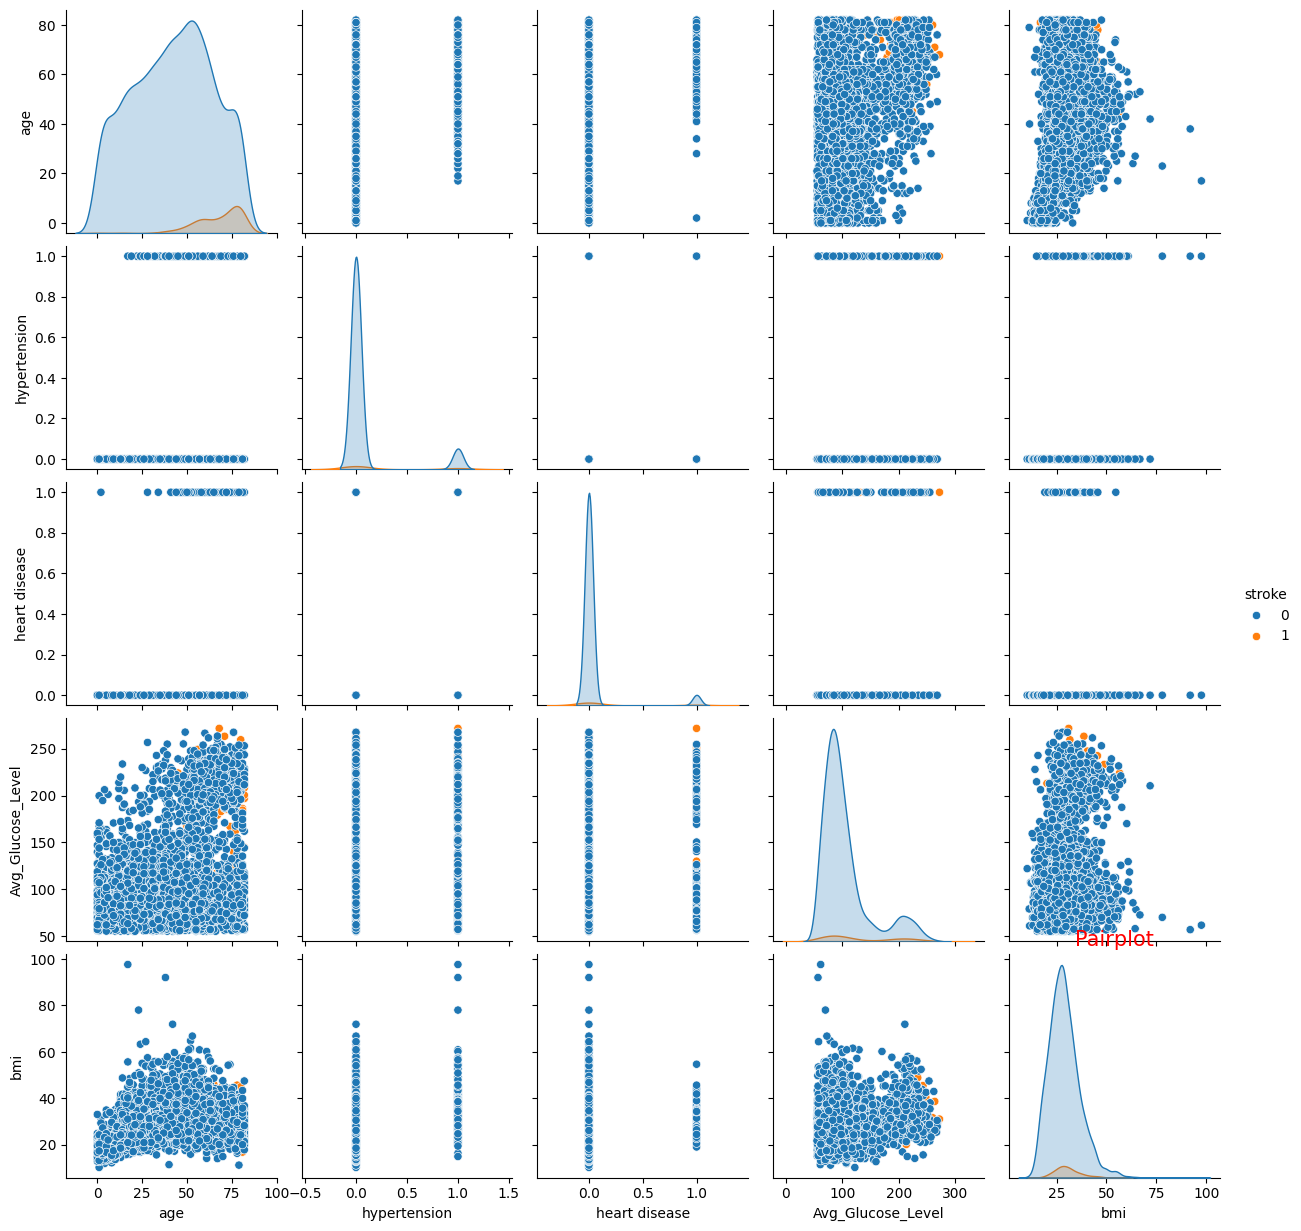

In [58]:
sns.pairplot(df,hue="stroke")
plt.title('Pairplot',color='red',fontsize=15)
plt.show()

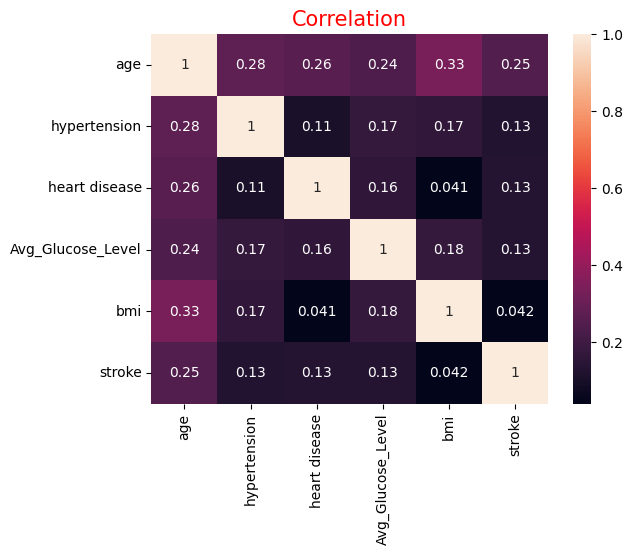

In [59]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation',color='red',fontsize=15)
plt.show()

# Data Encoding And Scaling

In [60]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

# Split X and Y

In [61]:
x=df.drop(columns=["stroke"],axis=1)
y=df["stroke"]

In [62]:
ohe=OneHotEncoder(handle_unknown='ignore')
ohe.fit(x[["gender","Married","Work Type","Residence_type","Smoking Status"]])

OneHotEncoder(handle_unknown='ignore')

In [63]:
ss=StandardScaler()
ss.fit(x[["age","Avg_Glucose_Level","bmi","heart disease","hypertension"]])

StandardScaler()

In [64]:
df.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Train Test Split

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Fill Nan Values

In [66]:
median_bmi = x_train['bmi'].median()
x_train['bmi'].fillna(median_bmi, inplace=True)
x_test['bmi'].fillna(median_bmi, inplace=True)

/tmp/ipykernel_3095/3066497001.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['bmi'].fillna(median_bmi, inplace=True)
/tmp/ipykernel_3095/3066497001.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [67]:
column_trans=make_column_transformer(
    (ohe,["gender","Married","Work Type","Residence_type","Smoking Status"]),
    (ss,["age","Avg_Glucose_Level","bmi","heart disease","hypertension"]),
    remainder="passthrough"
)

In [68]:
column_trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Married', 'Work Type',
                                  'Residence_type', 'Smoking Status']),
                                ('standardscaler', StandardScaler(),
                                 ['age', 'Avg_Glucose_Level', 'bmi',
                                  'heart disease', 'hypertension'])])

In [69]:
x_train_tranform=column_trans.fit_transform(x_train)
x_test_transform=column_trans.transform(x_test)

In [70]:
# from imblearn.over_sampling import SMOTE
# oversample = SMOTE(random_state=42)
# X_train_resh, y_train_resh = oversample.fit_resample(x_train_tranform, y_train)

# Balance the Data using ADASYN

In [71]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_res, y_res = adasyn.fit_resample(x_train_tranform, y_train)

In [72]:
x_train

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status
802,Male,79,0,0,Yes,Self-employed,Rural,112.64,28.5,formerly smoked
3927,Female,62,0,0,Yes,Private,Urban,88.32,36.3,Unknown
2337,Female,21,0,0,No,Private,Rural,59.52,33.7,never smoked
3910,Male,31,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked
1886,Female,31,0,0,No,Private,Rural,59.63,19.9,never smoked
...,...,...,...,...,...,...,...,...,...,...
4427,Female,61,0,0,Yes,Private,Rural,144.14,29.8,never smoked
466,Female,61,1,0,Yes,Private,Rural,170.05,60.2,smokes
3092,Female,1,0,0,No,children,Urban,97.28,17.8,Unknown
3773,Female,38,0,0,Yes,Govt_job,Rural,93.93,21.5,never smoked


In [73]:
x.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked


In [74]:
y.head()

,stroke
0,1
1,1
2,1
3,1
4,1


In [75]:
x.shape

(5109, 10)

In [76]:
y.shape

(5109,)

In [77]:
# X_train_resh.shape

In [78]:
pd.Series(y_train).value_counts()

,count
stroke,
0,3900
1,187


In [79]:
# pd.Series(y_train_resh).value_counts()

# **Data Modeling With Artifical Neural Network (ANN) Architecture**

# Import Tensorflow Library

In [80]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [81]:
# Dropout randomly turns off neurons during training.


model = tf.keras.Sequential([
    # Input Layers
    tf.keras.layers.InputLayer(input_shape=(X_res.shape[1],)),


    # dense Layers
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),



    # Output Layers
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


# Model Summary

In [82]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
from tensorflow.keras.metrics import F1Score,Accuracy,Precision,Recall,AUC
from tensorflow.keras.callbacks import EarlyStopping

In [96]:
model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy','Precision','Recall','f1_score']
)

# **Early Stoping:**
Early Stopping is a technique used in machine learning and deep learning (including TensorFlow) to stop training automatically when the model stops improving on validation data

In [85]:
# early stopping
early_stop = EarlyStopping(
    monitor='val_recall',
    patience=5,
    mode='max',
    restore_best_weights=True
)


## 📊 **Model Performance Interpretation Theory**

### 🔴 1. Training accuracy >> Validation accuracy

This indicates **overfitting**.
The model performs very well on training data but poorly on unseen validation data, meaning it has memorized the training data instead of learning general patterns.

---

### 🟡 2. Training accuracy << Validation accuracy

This is uncommon and may indicate **underfitting or data mismatch**.
The model is not learning the training data properly, or validation data may be easier than training data.

---

### 🟢 3. Training accuracy ≈ Validation accuracy

This indicates a **well-balanced model (good fit)**.
The model has learned general patterns and performs consistently on both training and validation data, showing good generalization.

---


In [86]:

# from sklearn.utils import class_weight
# # compute weights

# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weights = {
#     0:1,   # majority class
#     1:19.5    # minority class (increase importance)
# }


In [97]:
history = model.fit(
    X_res,
    y_res,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    # class_weight=class_weights,
    callbacks=[early_stop]


)

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - Precision: 0.9660 - Recall: 0.9771 - accuracy: 0.9784 - f1_score: 0.6502 - loss: 0.0617 - val_Precision: 1.0000 - val_Recall: 0.9086 - val_accuracy: 0.9086 - val_f1_score: 1.0000 - val_loss: 0.2162
Epoch 2/100


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: Precision,Recall,accuracy,f1_score,loss,val_Precision,val_Recall,val_accuracy,val_f1_score,val_loss
  current = self.get_monitor_value(logs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - Precision: 0.9648 - Recall: 0.9779 - accuracy: 0.9783 - f1_score: 0.6521 - loss: 0.0586 - val_Precision: 1.0000 - val_Recall: 0.9150 - val_accuracy: 0.9150 - val_f1_score: 1.0000 - val_loss: 0.1988
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - Precision: 0.9627 - Recall: 0.9754 - accuracy: 0.9765 - f1_score: 0.6525 - loss: 0.0597 - val_Precision: 1.0000 - val_Recall: 0.9693 - val_accuracy: 0.9693 - val_f1_score: 1.0000 - val_loss: 0.1017
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.9620 - Recall: 0.9775 - accuracy: 0.9770 - f1_score: 0.6526 - loss: 0.0585 - val_Precision: 1.0000 - val_Recall: 0.9304 - val_accuracy: 0.9304 - val_f1_score: 1.0000 - val_loss: 0.1477
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - Precision: 0.9676 - Recall: 0.9767 - accuracy: 0.9789 - f1_score: 0.6551 - loss: 0.0573 - val_Precision: 1.0000 - val_Recall: 0.9348 - val_accuracy: 0.9348 - val_f1_score: 1.0000 - val_loss: 0.1451

# Evaluation of Result

In [98]:
loss, accuracy, precision, recall,f1_score= model.evaluate(X_res,y_res)
print(f"Loss: {loss*100}")
print(f"Accuracy: {accuracy*100}")
print(f"Precision: {precision*100}")
print(f"Recall: {recall}")
print(f"f1_score: {f1_score}")

245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.9839 - Recall: 0.9796 - accuracy: 0.9817 - f1_score: 0.7953 - loss: 0.0510
Loss: 5.102476850152016
Accuracy: 98.17182421684265
Precision: 98.3866810798645
Recall: 0.9796022176742554
f1_score: 0.7952955365180969


# Graph Representation Of Training Loss & Validation Loss

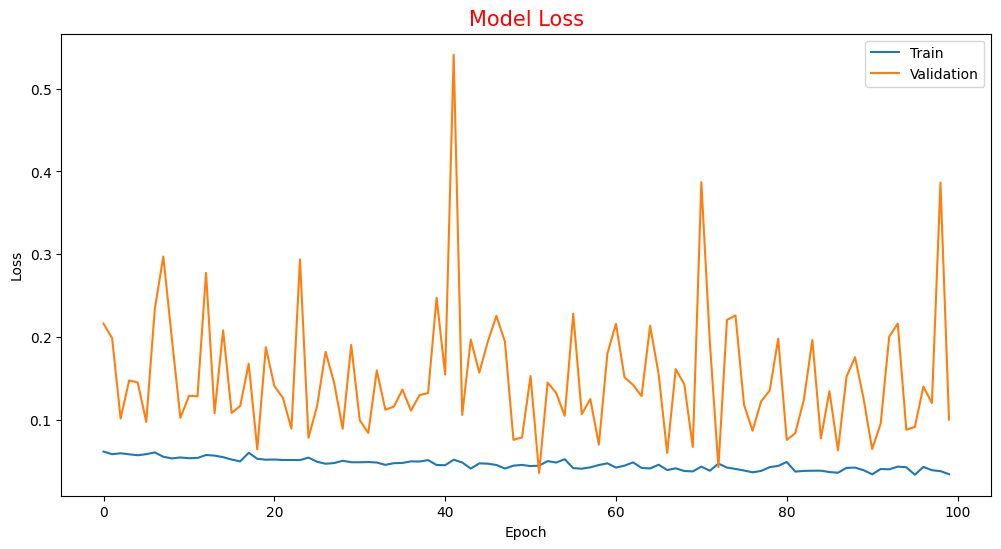

In [99]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss',color='red',fontsize=15)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()


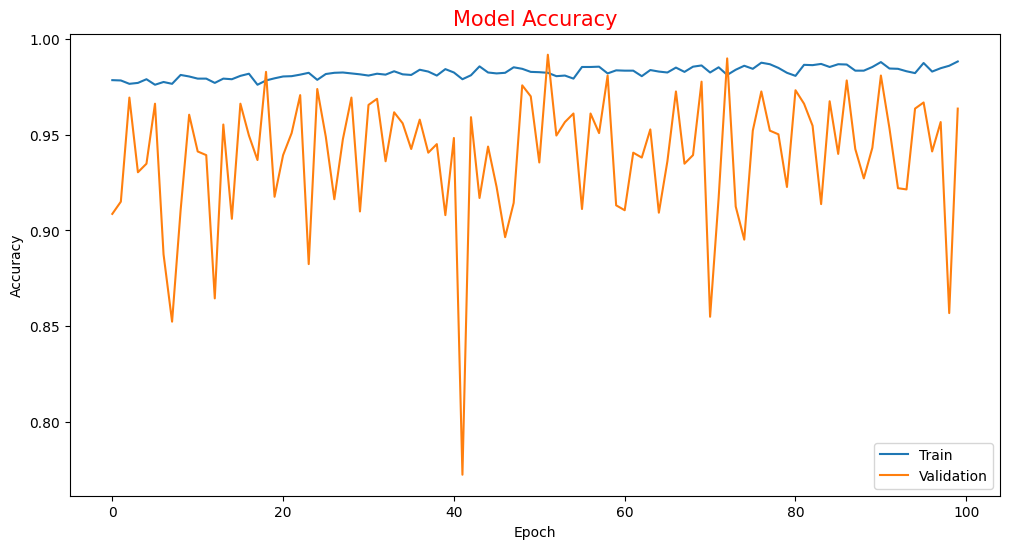

In [100]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy',color='red',fontsize=15)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'],loc='lower right')
plt.show()

# **Test the Prediction**

In [91]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart disease', 'Married',
       'Work Type', 'Residence_type', 'Avg_Glucose_Level', 'bmi',
       'Smoking Status', 'stroke'],
      dtype='object')

In [92]:
new_data = pd.DataFrame({
    'gender': ['Male'],
    'age': [67],
    'hypertension': [0],
    'heart disease': [1],
    'Married': ['Yes'],
    'Work Type': ['Private'],
    'Residence_type': ['Urban'],
    'Avg_Glucose_Level': [228.69],
    'bmi': [36.6],
    'Smoking Status': ['formerly smoked']
})



new_data_transformed = column_trans.transform(new_data)

In [93]:
prediction = model.predict(new_data_transformed)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
[[0.9876826]]


In [94]:
prediction_class = (prediction > 0.5).astype(int)
print(prediction_class)

[[1]]


In [95]:
df.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
